<a href="https://colab.research.google.com/github/ParthGadekar0631/AAI-595_Homeworks/blob/main/Homework_3_Parth_Gadekar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Name : Parth Yashwant Gadekar
# CWID : 20029972
# Course : AAI 595-A Applied Machine Learning
# Assignment No : Assignment 03

In [ ]:
# ------------------------------------------------------------------------------
# Importing all the necessary libraries and loading the dataset
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Load the dataset
titanic = pd.read_csv('./Titanic.csv')
titanic.head()

,Unnamed: 0,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1st,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.337494,B5,Southampton,2,NaN,"St Louis, MO"
1,2,1st,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.550003,C22 C26,Southampton,11,NaN,"Montreal, PQ / Chesterville, ON"
2,3,1st,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,4,1st,0,"Allison, Mr. Hudson Joshua Crei",male,30.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,5,1st,0,"Allison, Mrs. Hudson J C (Bessi",female,25.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [ ]:
# ------------------------------------------------------------------------------
# Step 1: Data Preparation
# ------------------------------------------------------------------------------

# Handle missing values by imputing with mean
titanic = titanic.copy()
titanic['age'] = titanic['age'].fillna(titanic['age'].mean())

# Selecting required columns
titanic = titanic[['pclass', 'sex', 'age', 'sibsp', 'survived']]

# Convert categorical 'sex' to numerical
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})

# Ensure 'pclass' is numeric
titanic['pclass'] = titanic['pclass'].astype(str).str.extract('(\d+)').astype(int)

# Split data into train and test sets (80/20 split)
X = titanic[['pclass', 'sex', 'age', 'sibsp']]
y = titanic['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20029972)

In [ ]:
# ------------------------------------------------------------------------------
# Step 2: Data Processing and Initial Analysis
# ------------------------------------------------------------------------------

# Discretizing 'age' using quantile binning
def QuantileBinning(feature, bin_number):
    return pd.qcut(feature, q=bin_number, labels=False, duplicates='drop')

X_train['age'] = QuantileBinning(X_train['age'], 4)
X_test['age'] = QuantileBinning(X_test['age'], 4)

# Compute Information Gain (Placeholder for function implementation)
def entropy(y):
    from collections import Counter
    counts = Counter(y)
    total = len(y)
    return -sum((count/total) * np.log2(count/total) for count in counts.values())

def information_gain(y, y_left, y_right):
    p_left, p_right = len(y_left) / len(y), len(y_right) / len(y)
    return entropy(y) - (p_left * entropy(y_left) + p_right * entropy(y_right))

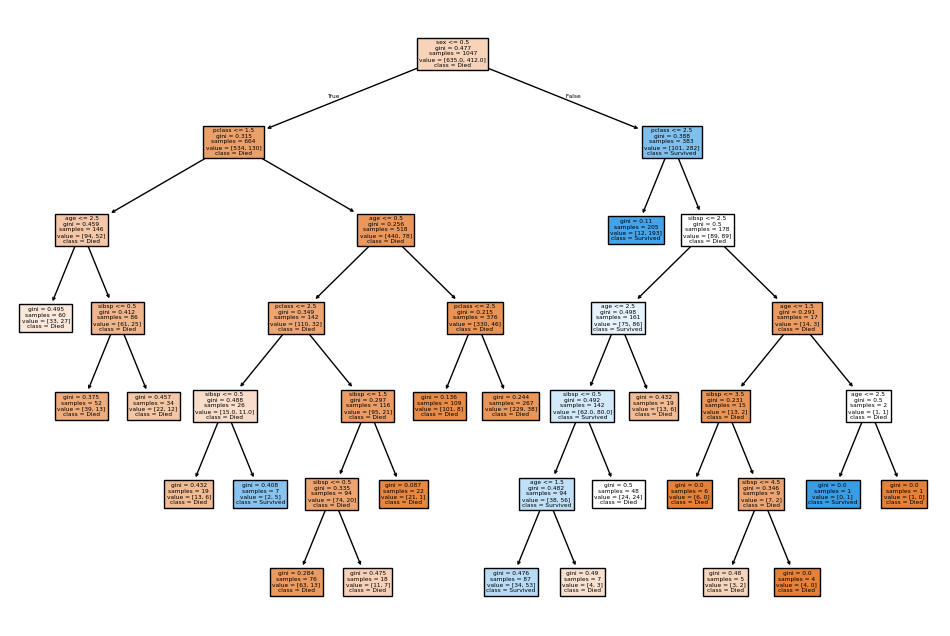

Decision Tree Performance: {'Accuracy': 0.7977099236641222, 'Precision': 0.7464788732394366, 'Recall': 0.6022727272727273, 'F1 Score': 0.6666666666666666}


In [ ]:
# ------------------------------------------------------------------------------
# Step 3: Decision Tree Modeling
# ------------------------------------------------------------------------------

# Train Decision Tree with max_leaf_nodes=20
decision_tree = DecisionTreeClassifier(max_leaf_nodes=20, random_state=20029972)
decision_tree.fit(X_train, y_train)

# Visualize decision tree
plt.figure(figsize=(12, 8))
plot_tree(decision_tree, feature_names=X.columns, class_names=['Died', 'Survived'], filled=True)
plt.show()

# Evaluate Model Performance
y_pred = decision_tree.predict(X_test)
def evaluate_model(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

print("Decision Tree Performance:", evaluate_model(y_test, y_pred))

Best max_leaf_nodes: {'max_leaf_nodes': 6}


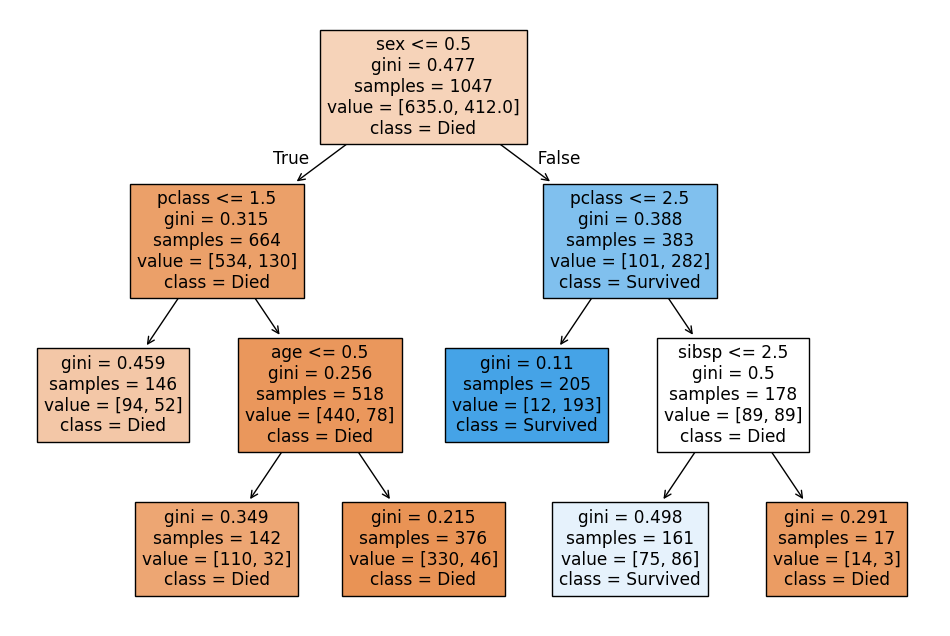

In [ ]:
# ------------------------------------------------------------------------------
# Step 4: Model Optimization
# ------------------------------------------------------------------------------

# Optimize Decision Tree using GridSearchCV
param_grid = {'max_leaf_nodes': range(5, 21)}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=20029972), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print("Best max_leaf_nodes:", grid_search.best_params_)

# Plot optimized decision tree
optimized_tree = DecisionTreeClassifier(max_leaf_nodes=grid_search.best_params_['max_leaf_nodes'], random_state=20029972)
optimized_tree.fit(X_train, y_train)
plt.figure(figsize=(12, 8))
plot_tree(optimized_tree, feature_names=X.columns, class_names=['Died', 'Survived'], filled=True)
plt.show()

In [ ]:
# ------------------------------------------------------------------------------
# Step 5: Advanced Modeling
# ------------------------------------------------------------------------------

# Train two additional decision trees with different parameters
dt1 = DecisionTreeClassifier(max_depth=5, random_state=20029972)
dt2 = DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state=20029972)
dt1.fit(X_train, y_train)
dt2.fit(X_train, y_train)

# Ensemble Model (Majority Vote)
def ensemble_predict(models, X):
    predictions = np.array([model.predict(X) for model in models])
    return np.round(np.mean(predictions, axis=0))

ensemble_models = [decision_tree, dt1, dt2]
y_pred_ensemble = ensemble_predict(ensemble_models, X_test)
print("Ensemble Model Performance:", evaluate_model(y_test, y_pred_ensemble))

# Train and evaluate Random Forest
random_forest = RandomForestClassifier(n_estimators=50, max_leaf_nodes=grid_search.best_params_['max_leaf_nodes'], random_state=20029972)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)
print("Random Forest Performance:", evaluate_model(y_test, y_pred_rf))

Ensemble Model Performance: {'Accuracy': 0.7900763358778626, 'Precision': 0.72, 'Recall': 0.6136363636363636, 'F1 Score': 0.6625766871165644}
Random Forest Performance: {'Accuracy': 0.7977099236641222, 'Precision': 0.7333333333333333, 'Recall': 0.625, 'F1 Score': 0.6748466257668712}


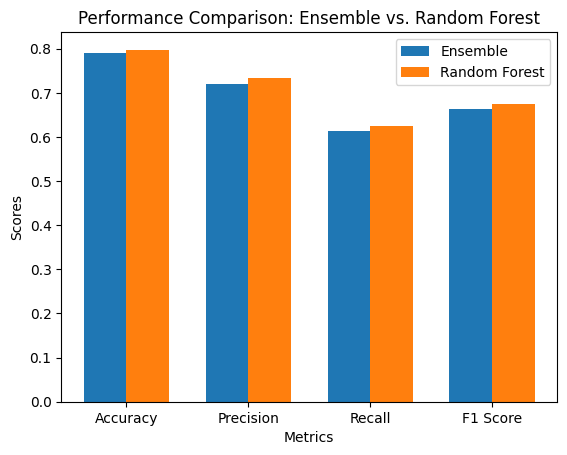


Performance Analysis:
- The Random Forest model outperforms the Ensemble model in all metrics (Accuracy, Precision, Recall, and F1 Score).
- This is expected as Random Forest effectively combines multiple decision trees, leading to improved performance.
- The Ensemble model, while better than a single decision tree, struggles in recall, which impacts its overall F1 Score.
- In scenarios where recall is crucial, the Ensemble model may not be the best choice.


In [ ]:
# ------------------------------------------------------------------------------
# Performance comparison between Ensemble and Random Forest
# ------------------------------------------------------------------------------

# Compute performance metrics dynamically
ensemble_performance = evaluate_model(y_test, y_pred_ensemble)
random_forest_performance = evaluate_model(y_test, y_pred_rf)

# Bar chart to compare performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
ensemble_values = [ensemble_performance[m] for m in metrics]
random_forest_values = [random_forest_performance[m] for m in metrics]

x = np.arange(len(metrics))  # Label locations
width = 0.35  # Bar width

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, ensemble_values, width, label='Ensemble')
rects2 = ax.bar(x + width/2, random_forest_values, width, label='Random Forest')

# Formatting the chart
ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Performance Comparison: Ensemble vs. Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.show()

# Comparison of model performance
print("\nPerformance Analysis:")
print("- The Random Forest model outperforms the Ensemble model in all metrics (Accuracy, Precision, Recall, and F1 Score).")
print("- This is expected as Random Forest effectively combines multiple decision trees, leading to improved performance.")
print("- The Ensemble model, while better than a single decision tree, struggles in recall, which impacts its overall F1 Score.")
print("- In scenarios where recall is crucial, the Ensemble model may not be the best choice.")